<a href="https://colab.research.google.com/github/eduardogapanowicz/programacao/blob/main/Trabalho%20Final%20da%20P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de Classificação de Texto em Português

**Objetivo:** Classificar avaliações de produtos em português (positivo, neutro, negativo) usando múltiplos algoritmos de aprendizado supervisionado.

**Dataset:** Amazon Reviews Multilingual — subconjunto em português brasileiro, disponível publicamente via HuggingFace Datasets  
**URL:** https://huggingface.co/datasets/amazon_reviews_multi

**Pipeline:**
1. Carregamento e inspeção do dataset
2. Limpeza e pré-processamento
3. Extração de features (TF-IDF)
4. Treinamento de múltiplos classificadores
5. Validação e comparação (acurácia, F1, matriz de confusão)
6. Teste com novos textos

In [ ]:
!pip install datasets nltk scikit-learn matplotlib seaborn wordcloud unidecode -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.5 MB/s eta 0:00:00


In [ ]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from unidecode import unidecode

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from datasets import load_dataset

nltk.download('stopwords', quiet=True)
nltk.download('rslp', quiet=True)

SEED = 42
np.random.seed(SEED)
print('Importações concluídas.')

Importações concluídas.


## 3. Carregamento do Dataset

Usamos o [Amazon Reviews Multilingual](https://huggingface.co/datasets/amazon_reviews_multi) — subset `pt` (português), disponível publicamente no HuggingFace.

O campo `review_body` contém o texto da avaliação e `stars` (1–5) é o rótulo de estrelas.

In [ ]:
import pandas as pd

URL = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

print('Baixando dataset B2W-Reviews01 (avaliações em português)...')
df_raw = pd.read_csv(URL)

print(f'Total de registros: {len(df_raw):,}')
print(f'Colunas: {df_raw.columns.tolist()}')
df_raw.head(5)

Baixando dataset B2W-Reviews01 (avaliações em português)...
Total de registros: 132,373
Colunas: ['submission_date', 'reviewer_id', 'product_id', 'product_name', 'product_brand', 'site_category_lv1', 'site_category_lv2', 'review_title', 'overall_rating', 'recommend_to_a_friend', 'review_text', 'reviewer_birth_year', 'reviewer_gender', 'reviewer_state']


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG


Registros removidos (duplicatas): 2374
Registros restantes: 126,724

Distribuição:
classe
positivo    78275
negativo    32600
neutro      15849
Name: count, dtype: int64


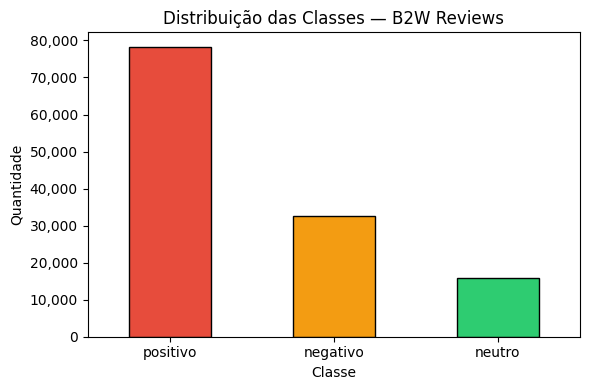

In [ ]:
df = df_raw[['review_text', 'overall_rating']].copy()
df.rename(columns={'review_text': 'texto', 'overall_rating': 'estrelas'}, inplace=True)

df.dropna(subset=['texto', 'estrelas'], inplace=True)
df['estrelas'] = pd.to_numeric(df['estrelas'], errors='coerce')
df.dropna(subset=['estrelas'], inplace=True)
df['estrelas'] = df['estrelas'].astype(int)

def mapear_sentimento(estrelas):
    if estrelas <= 2:
        return 'negativo'
    elif estrelas == 3:
        return 'neutro'
    else:
        return 'positivo'

df['classe'] = df['estrelas'].apply(mapear_sentimento)

antes = len(df)
df.drop_duplicates(subset='texto', inplace=True)
depois = len(df)
print(f'Registros removidos (duplicatas): {antes - depois}')
print(f'Registros restantes: {depois:,}')
print('\nDistribuição:')
print(df['classe'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['classe'].value_counts().plot(kind='bar', ax=ax,
    color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax.set_title('Distribuição das Classes — B2W Reviews')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
MIN_POR_CLASSE = 5000

df_bal = (
    df.groupby('classe', group_keys=False)
      .apply(lambda g: g.sample(min(len(g), MIN_POR_CLASSE), random_state=SEED))
      .reset_index(drop=True)
)

print('Distribuição após balanceamento:')
print(df_bal['classe'].value_counts())
print(f'Total: {len(df_bal):,}')

Distribuição após balanceamento:
classe
negativo    5000
neutro      5000
positivo    5000
Name: count, dtype: int64
Total: 15,000


In [ ]:
STOPWORDS_PT = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

def preprocessar(texto: str, usar_stemming: bool = False) -> str:
    texto = texto.lower()
    texto = unidecode(texto)
    texto = re.sub(r'https?\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = [t for t in texto.split() if t not in STOPWORDS_PT and len(t) > 2]
    if usar_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

df_bal['texto_limpo'] = df_bal['texto'].apply(preprocessar)

pd.set_option('display.max_colwidth', 120)
df_bal[['texto', 'texto_limpo', 'classe']].sample(5, random_state=SEED)

,texto,texto_limpo,classe
11499,"Ótimo filme, comprem antes que saia de catálogo. Versão simples.",otimo filme comprem antes saia catalogo versao simples,positivo
6475,Gostei muito do produto e o recomendo aos interessados em pedalar,gostei produto recomendo interessados pedalar,neutro
13167,Comprei para meu filho esta tudo bem.não teve defeito nenhum recomendo a todos,comprei filho tudo bem nao defeito nenhum recomendo todos,positivo
862,Quando compra e uma beleza...acabou 1 ano e ela pifa não tem assistência q consiga arrumar e fica tão caro quanto co...,compra beleza acabou ano pifa nao assistencia consiga arrumar fica tao caro quanto comprar outra nao comprem produto...,negativo
5970,Chegou bem embalado e em perfeitas condições de uso.,chegou bem embalado perfeitas condicoes uso,neutro


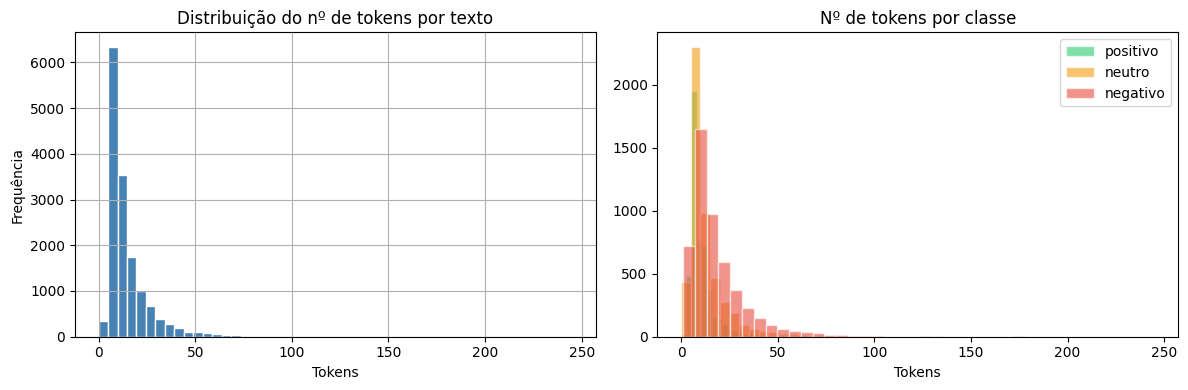

count    15000.0
mean        14.6
std         12.8
min          0.0
25%          7.0
50%         10.0
75%         17.0
max        245.0
Name: n_tokens, dtype: float64


In [ ]:
df_bal['n_tokens'] = df_bal['texto_limpo'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_bal['n_tokens'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do nº de tokens por texto')
axes[0].set_xlabel('Tokens')
axes[0].set_ylabel('Frequência')

for classe, cor in zip(['positivo','neutro','negativo'], ['#2ecc71','#f39c12','#e74c3c']):
    sub = df_bal[df_bal['classe'] == classe]['n_tokens']
    axes[1].hist(sub, bins=40, alpha=0.6, label=classe, color=cor, edgecolor='white')
axes[1].set_title('Nº de tokens por classe')
axes[1].set_xlabel('Tokens')
axes[1].legend()
plt.tight_layout()
plt.show()
print(df_bal['n_tokens'].describe().round(1))

In [ ]:
X = df_bal['texto_limpo'].values
y = df_bal['classe'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f'Dimensão da matriz TF-IDF (treino): {X_train_tfidf.shape}')

Treino: 12,000 | Teste: 3,000
Dimensão da matriz TF-IDF (treino): (12000, 11791)


In [ ]:
modelos = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Regressão Logística': LogisticRegression(max_iter=1000, C=5, random_state=SEED),
    'SVM Linear':          LinearSVC(C=1.0, max_iter=2000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = {}
print('Validação cruzada (5-fold) — aguarde...\n')

for nome, modelo in modelos.items():
    cv_res = cross_validate(modelo, X_train_tfidf, y_train, cv=cv,
                            scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
    acc_mean = cv_res['test_accuracy'].mean()
    acc_std  = cv_res['test_accuracy'].std()
    f1_mean  = cv_res['test_f1_weighted'].mean()
    resultados_cv[nome] = {'acc_mean': acc_mean, 'acc_std': acc_std, 'f1_mean': f1_mean}
    print(f'{nome:25s}  Acc: {acc_mean:.4f} ± {acc_std:.4f}  |  F1-W: {f1_mean:.4f}')

print('\nValidação concluída.')

Validação cruzada (5-fold) — aguarde...

Naive Bayes                Acc: 0.6865 ± 0.0071  |  F1-W: 0.6836
Regressão Logística        Acc: 0.6987 ± 0.0054  |  F1-W: 0.6977
SVM Linear                 Acc: 0.6899 ± 0.0071  |  F1-W: 0.6880
Random Forest              Acc: 0.6897 ± 0.0084  |  F1-W: 0.6841

Validação concluída.


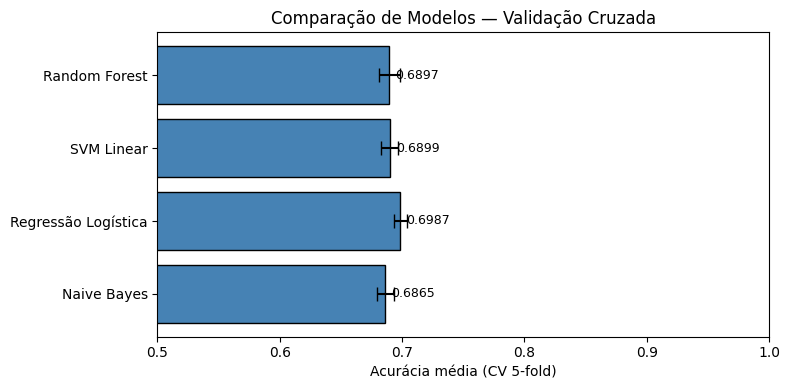

In [ ]:
df_cv = pd.DataFrame(resultados_cv).T.reset_index().rename(columns={'index': 'Modelo'})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df_cv['Modelo'], df_cv['acc_mean'],
               xerr=df_cv['acc_std'], capsize=5, color='steelblue', edgecolor='black')
ax.set_xlabel('Acurácia média (CV 5-fold)')
ax.set_title('Comparação de Modelos — Validação Cruzada')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, df_cv['acc_mean']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
melhor_nome = max(resultados_cv, key=lambda k: resultados_cv[k]['acc_mean'])
print(f'Melhor modelo selecionado: {melhor_nome}\n')

melhor_modelo = modelos[melhor_nome]
melhor_modelo.fit(X_train_tfidf, y_train)
y_pred = melhor_modelo.predict(X_test_tfidf)

print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['negativo','neutro','positivo']))
print(f'Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Weighted no teste: {f1_score(y_test, y_pred, average="weighted"):.4f}')

Melhor modelo selecionado: Regressão Logística

=== Relatório de Classificação ===
              precision    recall  f1-score   support

    negativo       0.81      0.82      0.81      1000
      neutro       0.59      0.58      0.58      1000
    positivo       0.71      0.71      0.71      1000

    accuracy                           0.70      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.70      0.70      0.70      3000

Acurácia no teste: 0.7017
F1-Weighted no teste: 0.7011


In [ ]:
print('=== Acurácia no Teste — Todos os Modelos ===\n')
resultados_teste = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    preds = modelo.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    resultados_teste[nome] = {'acc': acc, 'f1': f1}
    print(f'{nome:25s}  Acc: {acc:.4f}  |  F1-W: {f1:.4f}')

=== Acurácia no Teste — Todos os Modelos ===

Naive Bayes                Acc: 0.6983  |  F1-W: 0.6963
Regressão Logística        Acc: 0.7017  |  F1-W: 0.7011
SVM Linear                 Acc: 0.7003  |  F1-W: 0.6987
Random Forest              Acc: 0.6933  |  F1-W: 0.6873


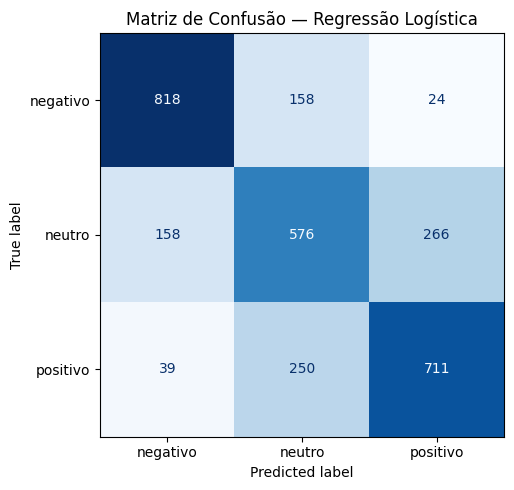

In [ ]:
labels = ['negativo', 'neutro', 'positivo']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusão — {melhor_nome}')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import FunctionTransformer

def preprocessar_array(textos):
    return np.array([preprocessar(t) for t in textos])

pipeline_final = SKPipeline([
    ('preprocessar', FunctionTransformer(preprocessar_array)),
    ('tfidf',        TfidfVectorizer(ngram_range=(1, 2), max_features=50_000,
                                     min_df=3, sublinear_tf=True)),
    ('clf',          modelos[melhor_nome].__class__(**modelos[melhor_nome].get_params())),
])

pipeline_final.fit(X_train, y_train)
y_pred_pipe = pipeline_final.predict(X_test)
print(f'Acurácia do pipeline final no teste: {accuracy_score(y_test, y_pred_pipe):.4f}')
print('Pipeline pronto!')

Acurácia do pipeline final no teste: 0.7017
Pipeline pronto!


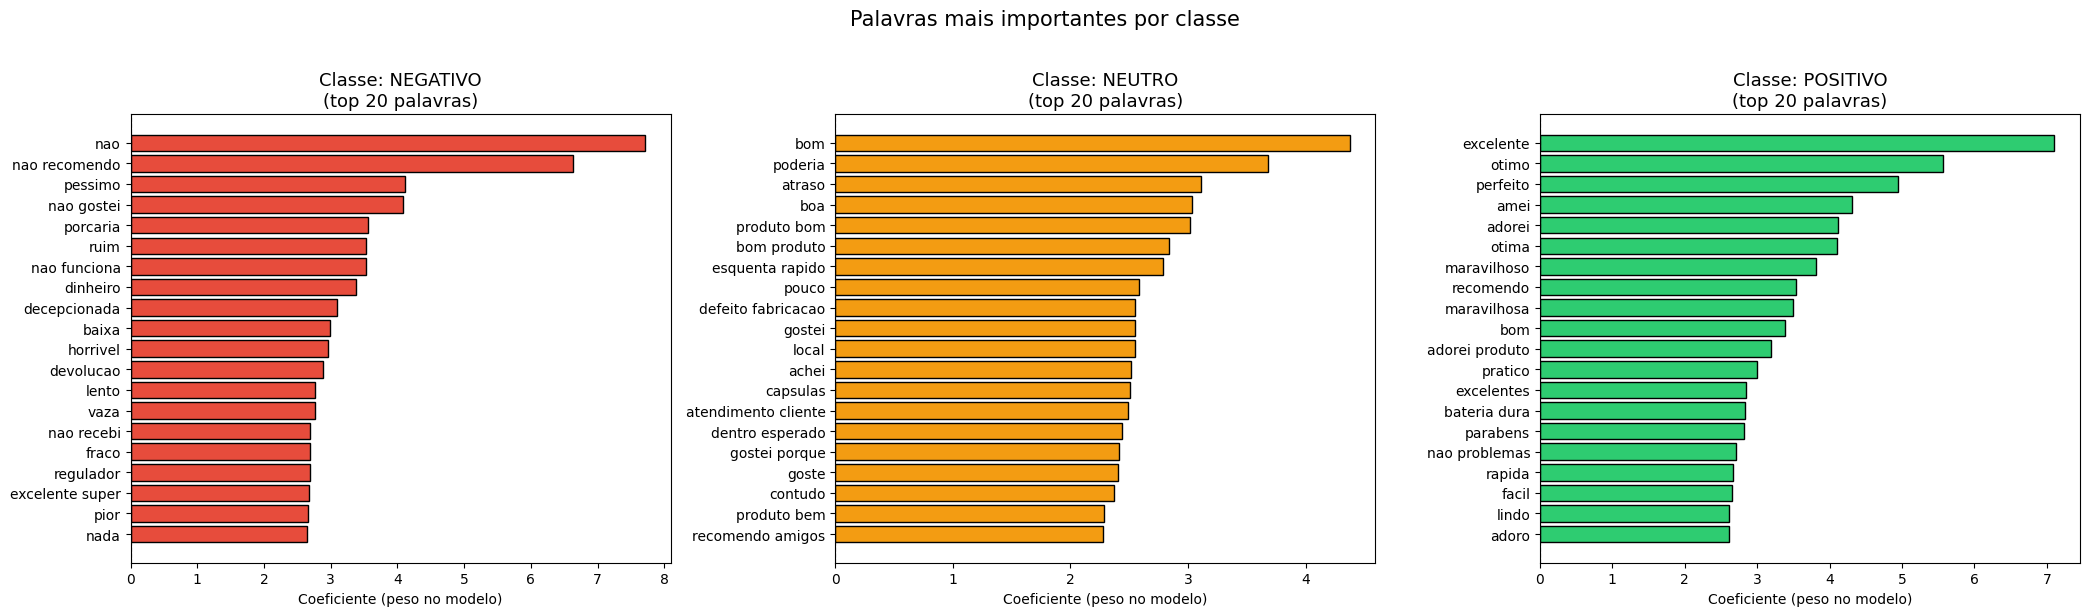

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def top_palavras_por_classe(pipeline, n=20):
    """Exibe as palavras com maior peso para cada classe no modelo treinado."""
    vectorizer = pipeline.named_steps['tfidf']
    clf        = pipeline.named_steps['clf']
    vocab      = vectorizer.get_feature_names_out()

    if not hasattr(clf, 'coef_'):
        print('Este modelo não expõe coeficientes por palavra.')
        return

    classes = clf.classes_
    n_classes = len(classes)
    cores = {'negativo': '#e74c3c', 'neutro': '#f39c12', 'positivo': '#2ecc71'}

    fig, axes = plt.subplots(1, n_classes, figsize=(7 * n_classes, 6))

    for ax, classe, coefs in zip(axes, classes, clf.coef_):
        idx_top    = np.argsort(coefs)[-n:]
        palavras   = vocab[idx_top]
        pesos      = coefs[idx_top]

        ax.barh(palavras, pesos, color=cores.get(classe, 'steelblue'), edgecolor='black')
        ax.set_title(f'Classe: {classe.upper()}\n(top {n} palavras)', fontsize=13)
        ax.set_xlabel('Coeficiente (peso no modelo)')
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    plt.suptitle('Palavras mais importantes por classe', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

top_palavras_por_classe(pipeline_final, n=20)

In [ ]:
novos_textos = [
    "Produto excelente! Chegou rápido e superou todas as minhas expectativas. Recomendo muito!",
    "Ótima qualidade, embalagem impecável e entrega antes do prazo. Muito satisfeita com a compra.",
    "Adorei! Funciona perfeitamente, material de boa qualidade e preço justo.",
    "O produto é razoável, nada de especial. Faz o que promete mas poderia ser melhor.",
    "Entrega no prazo, produto dentro do esperado. Nem bom nem ruim.",
    "Produto péssimo! Quebrou na primeira semana de uso. Não recomendo de jeito nenhum.",
    "Muito decepcionante. A qualidade é horrível e o atendimento foi um desastre.",
    "Não funciona como descrito. Perdi meu dinheiro. Produto falsificado!",
]

predicoes = pipeline_final.predict(novos_textos)

print('=== Classificação de Novos Textos ===\n')
for texto, classe in zip(novos_textos, predicoes):
    print(f'[{classe.upper():9s}] {texto[:85]}')
    print()

=== Classificação de Novos Textos ===

[POSITIVO ] Produto excelente! Chegou rápido e superou todas as minhas expectativas. Recomendo mu

[POSITIVO ] Ótima qualidade, embalagem impecável e entrega antes do prazo. Muito satisfeita com a

[POSITIVO ] Adorei! Funciona perfeitamente, material de boa qualidade e preço justo.

[NEUTRO   ] O produto é razoável, nada de especial. Faz o que promete mas poderia ser melhor.

[NEUTRO   ] Entrega no prazo, produto dentro do esperado. Nem bom nem ruim.

[NEGATIVO ] Produto péssimo! Quebrou na primeira semana de uso. Não recomendo de jeito nenhum.

[NEGATIVO ] Muito decepcionante. A qualidade é horrível e o atendimento foi um desastre.

[NEGATIVO ] Não funciona como descrito. Perdi meu dinheiro. Produto falsificado!




  ANÁLISE DE CLASSIFICAÇÃO — TEXTOS DE TESTE

Texto 1: "Produto excelente! Chegou rápido e superou todas as minhas expectativas. Re..."
  Esperado : 😊  POSITIVO
  Previsto : 😊  POSITIVO
  Status   : ✓ CORRETO  
  Confiança:
    positivo   [█████████████████████████████░]  99.6%
    neutro     [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.3%
    negativo   [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.1%

Texto 2: "Ótima qualidade, embalagem impecável e entrega antes do prazo. Muito satisf..."
  Esperado : 😊  POSITIVO
  Previsto : 😊  POSITIVO
  Status   : ✓ CORRETO  
  Confiança:
    positivo   [█████████████████████████████░]  97.0%
    neutro     [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   3.0%
    negativo   [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.0%

Texto 3: "Adorei! Funciona perfeitamente, material de boa qualidade e preço justo."
  Esperado : 😊  POSITIVO
  Previsto : 😊  POSITIVO
  Status   : ✓ CORRETO  
  Confiança:
    positivo   [███████████████████████████░░░]  90.7%
    neutro     [██░░░░░░░░░░░░░░░░░░░░

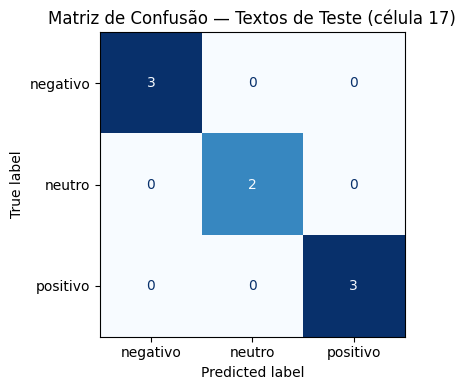


=== Relatório por Classe ===

              precision    recall  f1-score   support

    negativo       1.00      1.00      1.00         3
      neutro       1.00      1.00      1.00         2
    positivo       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

textos_teste = [
    ("Produto excelente! Chegou rápido e superou todas as minhas expectativas. Recomendo muito!",        "positivo"),
    ("Ótima qualidade, embalagem impecável e entrega antes do prazo. Muito satisfeita com a compra.",    "positivo"),
    ("Adorei! Funciona perfeitamente, material de boa qualidade e preço justo.",                         "positivo"),
    ("O produto é razoável, nada de especial. Faz o que promete mas poderia ser melhor.",                "neutro"),
    ("Entrega no prazo, produto dentro do esperado. Nem bom nem ruim.",                                  "neutro"),
    ("Produto péssimo! Quebrou na primeira semana de uso. Não recomendo de jeito nenhum.",               "negativo"),
    ("Muito decepcionante. A qualidade é horrível e o atendimento foi um desastre.",                     "negativo"),
    ("Não funciona como descrito. Perdi meu dinheiro. Produto falsificado!",                             "negativo"),
]

textos   = [t for t, _ in textos_teste]
gabarito = [g for _, g in textos_teste]

predicoes = pipeline_final.predict(textos)

tem_proba = hasattr(pipeline_final.named_steps['clf'], 'predict_proba')
if tem_proba:
    probas = pipeline_final.predict_proba(textos)
    classes_ordem = pipeline_final.named_steps['clf'].classes_
else:
    probas = None

VERDE    = '\033[92m'
VERMELHO = '\033[91m'
AMARELO  = '\033[93m'
RESET    = '\033[0m'
NEGRITO  = '\033[1m'

icone_classe = {'positivo': '😊', 'neutro': '😐', 'negativo': '😠'}

print(f"\n{'='*70}")
print(f"{NEGRITO}  ANÁLISE DE CLASSIFICAÇÃO — TEXTOS DE TESTE{RESET}")
print(f"{'='*70}\n")

acertos = 0
for i, (texto, esperado, previsto) in enumerate(zip(textos, gabarito, predicoes), 1):
    correto   = previsto == esperado
    acertos  += correto
    status    = f"{VERDE}✓ CORRETO  {RESET}" if correto else f"{VERMELHO}✗ ERRADO   {RESET}"
    cor_prev  = VERDE if correto else VERMELHO

    print(f"Texto {i}: \"{texto[:75]}{'...' if len(texto)>75 else ''}\"")
    print(f"  Esperado : {icone_classe[esperado]}  {NEGRITO}{esperado.upper()}{RESET}")
    print(f"  Previsto : {icone_classe[previsto]}  {cor_prev}{NEGRITO}{previsto.upper()}{RESET}")
    print(f"  Status   : {status}")

    if probas is not None:
        proba_dict = dict(zip(classes_ordem, probas[i-1]))
        barra_max  = 30
        print(f"  Confiança:")
        for cls in sorted(proba_dict, key=proba_dict.get, reverse=True):
            p       = proba_dict[cls]
            barra   = '█' * int(p * barra_max) + '░' * (barra_max - int(p * barra_max))
            destaque = NEGRITO if cls == previsto else ''
            print(f"    {destaque}{cls:10s}{RESET} [{barra}] {p*100:5.1f}%")

    print()

total    = len(textos)
pct      = acertos / total * 100
cor_pct  = VERDE if pct == 100 else (AMARELO if pct >= 75 else VERMELHO)

print(f"{'─'*70}")
print(f"{NEGRITO}  RESUMO{RESET}")
print(f"{'─'*70}")
print(f"  Acertos  : {acertos}/{total}  ({cor_pct}{pct:.0f}%{RESET})")
print()

for cls in ['positivo', 'neutro', 'negativo']:
    idx       = [i for i, g in enumerate(gabarito) if g == cls]
    acertos_c = sum(predicoes[i] == gabarito[i] for i in idx)
    total_c   = len(idx)
    cor       = VERDE if acertos_c == total_c else (AMARELO if acertos_c > 0 else VERMELHO)
    print(f"  {icone_classe[cls]}  {cls.upper():10s}: {cor}{acertos_c}/{total_c} corretos{RESET}")

print()

labels = ['negativo', 'neutro', 'positivo']
cm     = confusion_matrix(gabarito, predicoes, labels=labels)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Matriz de Confusão — Textos de Teste (célula 17)')
plt.tight_layout()
plt.show()

print("\n=== Relatório por Classe ===\n")
print(classification_report(gabarito, predicoes,
                             labels=labels,
                             target_names=labels,
                             zero_division=0))

In [ ]:
def classificar_texto(texto: str) -> str:
    classe = pipeline_final.predict([texto])[0]
    print(f'Texto  : {texto}')
    print(f'Classe : {classe.upper()}')
    return classe

classificar_texto("O produto chegou com defeito e o suporte não resolveu nada.")
print()
classificar_texto("Compra tranquila, produto ok, sem reclamações.")
print()
classificar_texto("Simplesmente incrível! Melhor compra que já fiz na vida!")

Texto  : O produto chegou com defeito e o suporte não resolveu nada.
Classe : NEGATIVO

Texto  : Compra tranquila, produto ok, sem reclamações.
Classe : NEGATIVO

Texto  : Simplesmente incrível! Melhor compra que já fiz na vida!
Classe : POSITIVO


'positivo'